# Simulación de Monte Carlo

In [3]:
import pandas as pd
import numpy as np
import joblib
import math
from tqdm import tqdm
from collections import defaultdict
import warnings

warnings.filterwarnings('ignore')
print("Librerías importadas. Entorno de simulación listo.")

Librerías importadas. Entorno de simulación listo.


In [4]:
# Cargamos el modelo XGBoost optimizado
ruta_modelo = '../models/xgb_best_model.pkl'
try:
    xgb_best = joblib.load(ruta_modelo)
    print("Modelo XGBoost cargado exitosamente.")
except FileNotFoundError:
    print(f"Error: No se encontró el modelo en {ruta_modelo}. Ejecuta el Cuaderno 02 primero.")

# 2. Cargar el ELO actual (El que raspamos de EloRatings.net)
# Si lo guardaste como CSV en el paso de scraping:
df_elo_actual = pd.read_csv('../data/processed/elo_current_2026.csv')
elo_dict_oficial = dict(zip(df_elo_actual['Equipo'], df_elo_actual['ELO_Oficial']))

# (Asegúrate de tener a los 48 clasificados en tu diccionario final)

print("Datos ELO base preparados para el inicio del torneo.")

Modelo XGBoost cargado exitosamente.
Datos ELO base preparados para el inicio del torneo.


In [5]:
# Grupos oficiales de la Copa del Mundo 2026
grupos_2026 = {
    'A': ['Mexico', 'South Africa', 'South Korea', 'Czech Republic'],
    'B': ['Canada', 'Bosnia and Herzegovina', 'Qatar', 'Switzerland'],
    'C': ['Brazil', 'Morocco', 'Haiti', 'Scotland'],
    'D': ['United States', 'Paraguay', 'Australia', 'Turkey'],
    'E': ['Germany', 'Curaçao', 'Ivory Coast', 'Ecuador'],
    'F': ['Netherlands', 'Japan', 'Sweden', 'Tunisia'],
    'G': ['Belgium', 'Egypt', 'Iran', 'New Zealand'],
    'H': ['Spain', 'Cape Verde', 'Saudi Arabia', 'Uruguay'],
    'I': ['France', 'Senegal', 'Iraq', 'Norway'],
    'J': ['Argentina', 'Algeria', 'Austria', 'Jordan'],
    'K': ['Portugal', 'DR Congo', 'Uzbekistan', 'Colombia'],
    'L': ['England', 'Croatia', 'Ghana', 'Panama']
}
print("Estructura de 48 equipos y 12 grupos cargada.")

Estructura de 48 equipos y 12 grupos cargada.


Funciones para la simulación

In [6]:
def simular_partido(equipo_local, equipo_visitante, modelo, elo_dict, es_fase_grupos=True):
    # Extraer ELO (si un equipo no está en el dict, asume 1500)
    elo_local = elo_dict.get(equipo_local, 1500)
    elo_visit = elo_dict.get(equipo_visitante, 1500)
    diferencia = elo_local - elo_visit
    
    # Ventaja de localía exclusiva para anfitriones
    home_adv = 1 if equipo_local in ['United States', 'Mexico', 'Canada'] else 0
    
    # Crear vector de entrada
    X_partido = pd.DataFrame([{
        'home_elo': elo_local, 'away_elo': elo_visit, 
        'elo_difference': diferencia, 'home_advantage': home_adv, 
        'is_friendly': 0
    }])
    
    # Obtener probabilidades y lanzar el "dado de Monte Carlo"
    probs = modelo.predict_proba(X_partido)[0]
    resultado = np.random.choice([0, 1, 2], p=probs)
    
    if resultado == 2:   return 1, 0, 3, 0  # Gana Local
    elif resultado == 0: return 0, 1, 0, 3  # Gana Visit
    else:                
        if not es_fase_grupos:
            # Penales basados en ELO
            prob_local_penales = elo_local / (elo_local + elo_visit)
            gana_local_penales = np.random.random() < prob_local_penales
            return (1, 0, 3, 0) if gana_local_penales else (0, 1, 0, 3)
        return 0, 0, 1, 1 # Empate en grupos

def simular_torneo_completo(grupos, modelo, elo_dict):
    clasificados_32 = []
    mejores_terceros_stats = []
    
    # 1. Fase de Grupos
    for letra, equipos in grupos.items():
        tabla = {eq: {'pts': 0, 'gf': 0, 'gc': 0, 'dif': 0} for eq in equipos}
        for i in range(len(equipos)):
            for j in range(i + 1, len(equipos)):
                gf1, gf2, pts1, pts2 = simular_partido(equipos[i], equipos[j], modelo, elo_dict, True)
                tabla[equipos[i]]['pts'] += pts1
                tabla[equipos[i]]['dif'] += (gf1 - gf2)
                tabla[equipos[j]]['pts'] += pts2
                tabla[equipos[j]]['dif'] += (gf2 - gf1)
        
        posiciones = sorted(tabla.keys(), key=lambda x: (tabla[x]['pts'], tabla[x]['dif']), reverse=True)
        clasificados_32.extend([posiciones[0], posiciones[1]])
        
        tercero = posiciones[2]
        mejores_terceros_stats.append({
            'equipo': tercero, 'pts': tabla[tercero]['pts'], 'dif': tabla[tercero]['dif']
        })
    
    # 2. Rescatar a los 8 mejores terceros
    mejores_terceros_ordenados = sorted(mejores_terceros_stats, key=lambda x: (x['pts'], x['dif']), reverse=True)[:8]
    clasificados_32.extend([t['equipo'] for t in mejores_terceros_ordenados])
    
    # 3. Fase Eliminatoria Directa
    equipos_vivos = clasificados_32
    while len(equipos_vivos) > 1:
        siguiente_ronda = []
        for i in range(0, len(equipos_vivos), 2):
            eq1, eq2 = equipos_vivos[i], equipos_vivos[i+1]
            gf1, gf2, pts1, pts2 = simular_partido(eq1, eq2, modelo, elo_dict, False)
            siguiente_ronda.append(eq1 if pts1 > pts2 else eq2)
        equipos_vivos = siguiente_ronda
        
    return equipos_vivos[0]

print("Funciones del simulador cargadas en memoria.")

Funciones del simulador cargadas en memoria.


In [7]:
ITERACIONES = 10000
campeones_historico = defaultdict(int)

print(f"Iniciando Simulación Monte Carlo ({ITERACIONES} iteraciones)...")

for _ in tqdm(range(ITERACIONES)):
    campeon = simular_torneo_completo(grupos_2026, xgb_best, elo_dict_oficial)
    campeones_historico[campeon] += 1

print("\n¡Simulación finalizada!")

Iniciando Simulación Monte Carlo (10000 iteraciones)...


100%|██████████| 10000/10000 [33:02<00:00,  5.04it/s]


¡Simulación finalizada!


In [8]:
# 1. Función para margen de error
def calcular_margen_error(prob_porcentaje, n_iteraciones=ITERACIONES):
    p = prob_porcentaje / 100
    z = 1.96 # IC del 95%
    error = z * math.sqrt((p * (1 - p)) / n_iteraciones)
    return error * 100

# 2. Construir DataFrame final
resultados = pd.DataFrame(list(campeones_historico.items()), columns=['Equipo', 'Victorias'])
resultados['Probabilidad (%)'] = (resultados['Victorias'] / ITERACIONES) * 100
resultados = resultados.sort_values('Victorias', ascending=False).reset_index(drop=True)

# 3. Extraer Top 5 y aplicar intervalos
top_5 = resultados.head(5).copy()
top_5['Margen Error (±%)'] = top_5['Probabilidad (%)'].apply(calcular_margen_error)
top_5['Límite Inf (%)'] = top_5['Probabilidad (%)'] - top_5['Margen Error (±%)']
top_5['Límite Sup (%)'] = top_5['Probabilidad (%)'] + top_5['Margen Error (±%)']

# 4. Imprimir formato final para el reporte
print("🏆🐙 --- EL ORÁCULO DEL BALÓN: TOP 5 FAVORITOS MUNDIAL 2026 --- 🐙🏆")
print("Según nuestro estimado Pulpo Pawl 🐙")
print("*" * 75)
for index, row in top_5.iterrows():
    print(f"{int(index)+1}. {row['Equipo']:<12} | "
          f"Victorias: {int(row['Victorias']):<5} | "
          f"Prob: {row['Probabilidad (%)']:>5.2f}% | "
          f"IC 95%: [{row['Límite Inf (%)']:>5.2f}% - {row['Límite Sup (%)']:>5.2f}%]")
print("*" * 75)

🏆🐙 --- EL ORÁCULO DEL BALÓN: TOP 5 FAVORITOS MUNDIAL 2026 --- 🐙🏆
Según nuestro estimado Pulpo Pawl 🐙
***************************************************************************
1. Spain        | Victorias: 2845  | Prob: 28.45% | IC 95%: [27.57% - 29.33%]
2. Argentina    | Victorias: 1655  | Prob: 16.55% | IC 95%: [15.82% - 17.28%]
3. France       | Victorias: 865   | Prob:  8.65% | IC 95%: [ 8.10% -  9.20%]
4. England      | Victorias: 800   | Prob:  8.00% | IC 95%: [ 7.47% -  8.53%]
5. Brazil       | Victorias: 434   | Prob:  4.34% | IC 95%: [ 3.94% -  4.74%]
***************************************************************************


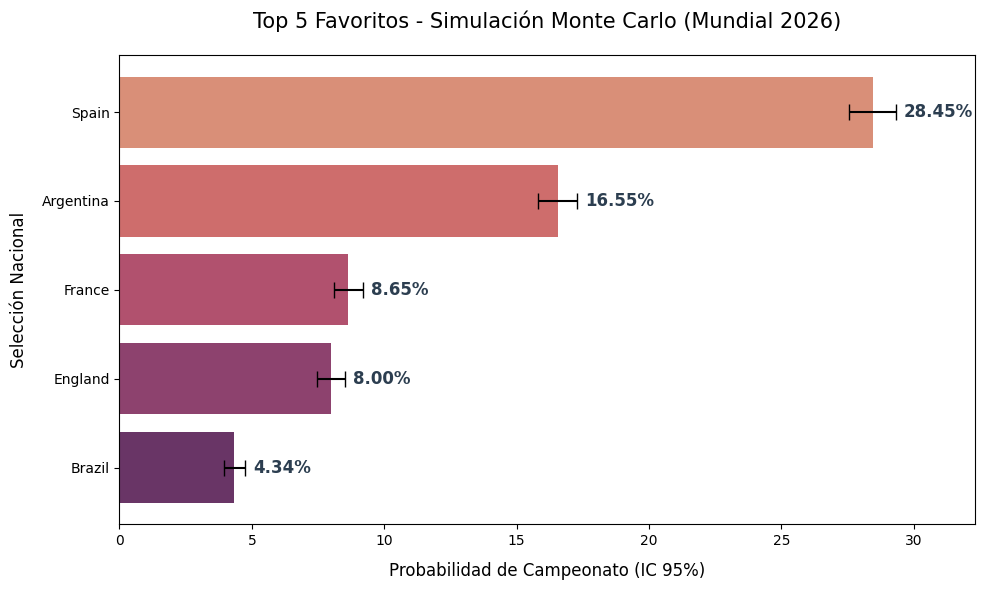


¡Gráfico del Top 5 generado y guardado exitosamente en /docs/figuras/!


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

ax = sns.barplot(x='Probabilidad (%)', y='Equipo', data=top_5, palette='flare')

# Añadir las barras de error (Intervalo de Confianza del 95%)
ax.errorbar(x=top_5['Probabilidad (%)'], y=top_5.index, 
            xerr=top_5['Margen Error (±%)'], 
            fmt='none', c='black', capsize=6, linewidth=1.5)

# Añadir el texto del porcentaje exacto
for i, p in enumerate(ax.patches):
    prob_val = top_5['Probabilidad (%)'].iloc[i]
    error_val = top_5['Margen Error (±%)'].iloc[i]
    
    # Posicionar el texto un poco a la derecha del margen de error para que no se encimen
    ax.text(prob_val + error_val + 0.3, 
            p.get_y() + p.get_height() / 2., 
            f'{prob_val:.2f}%', 
            ha='left', va='center', fontsize=12, fontweight='bold', color='#2c3e50')

plt.title('Top 5 Favoritos - Simulación Monte Carlo (Mundial 2026)', fontsize=15, pad=20)
plt.xlabel('Probabilidad de Campeonato (IC 95%)', fontsize=12, labelpad=10)
plt.ylabel('Selección Nacional', fontsize=12, labelpad=10)


max_x = top_5['Probabilidad (%)'].max() + top_5['Margen Error (±%)'].max() + 3
plt.xlim(0, max_x)

plt.tight_layout()

plt.savefig('../docs/figuras/top5_montecarlo.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n¡Gráfico del Top 5 generado y guardado exitosamente en /docs/figuras/!")